# 04. Grading the forecasts as risk models

Same six forecasts, a different job. Turn each one into a one day Value at Risk, a loss
line you should only cross about once in a hundred days, then check it the way a risk
team would: count the days the loss was worse than the line, and test whether there are
too many and whether they bunch together.

In [1]:
import sys
sys.path.append("..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.var_model import var_backtest, estimate_t_dof, var_series

MODELS = ["rolling", "ewma", "garch", "gjr", "egarch", "rf"]
fc = pd.read_csv("../data/processed/forecasts.csv", index_col=0, parse_dates=True)
r = fc["log_return"]

## 99 percent VaR, normal tail

Start with the textbook assumption that returns are normal.

In [2]:
rows = []
for m in MODELS:
    res = var_backtest(r, fc[m], alpha=0.99, dist="normal")
    rows.append({"model": m, "breaches": res["exceptions"], "rate_%": round(res["exception_rate"] * 100, 2),
                 "kupiec_p": round(res["kupiec_p"], 3), "independence_p": round(res["independence_p"], 3),
                 "cc_p": round(res["cc_p"], 3)})
pd.DataFrame(rows).set_index("model")

,breaches,rate_%,kupiec_p,independence_p,cc_p
model,,,,,
rolling,124,2.72,0.0,0.074,0.0
ewma,108,2.37,0.0,0.018,0.0
garch,96,2.10,0.0,0.207,0.0
gjr,96,2.10,0.0,0.988,0.0
egarch,101,2.21,0.0,0.870,0.0
rf,151,3.31,0.0,0.381,0.0


Every model breaches too often, 2 to 3 percent of days instead of 1 percent, so they all
fail the Kupiec count test. This is the fat tails problem: real markets throw more
extreme days than a bell curve allows. But look at the independence column already. The
GARCH breaches are spread out (high p), while rolling and EWMA breaches cluster (low p),
meaning the simple models go quiet right when risk is building.

## 99 percent VaR, fat tail

Now use a Student-t, which expects more extreme days. Its heaviness is read off each
model's own residuals.

In [3]:
rows = []
for m in MODELS:
    nu = estimate_t_dof(r / fc[m])                       # how fat the tail needs to be
    res = var_backtest(r, fc[m], alpha=0.99, dist="t", nu=nu)
    rows.append({"model": m, "nu": round(nu, 1), "breaches": res["exceptions"],
                 "rate_%": round(res["exception_rate"] * 100, 2), "kupiec_p": round(res["kupiec_p"], 3),
                 "independence_p": round(res["independence_p"], 3), "cc_p": round(res["cc_p"], 3)})
pd.DataFrame(rows).set_index("model")

,nu,breaches,rate_%,kupiec_p,independence_p,cc_p
model,,,,,,
rolling,5.5,102,2.24,0.000,0.010,0.000
ewma,5.9,83,1.82,0.000,0.021,0.000
garch,7.0,70,1.53,0.001,0.027,0.000
gjr,6.4,63,1.38,0.015,0.890,0.050
egarch,6.2,72,1.58,0.000,0.895,0.001
rf,6.4,108,2.37,0.000,0.392,0.000


The fat tail pulls every breach rate down towards 1 percent. GJR-GARCH is the one that
gets there cleanly: about 1.4 percent breaches, well spread, and it passes the combined
test with a p value right on the line. It is the only model here you could sign off as a
99 percent VaR.

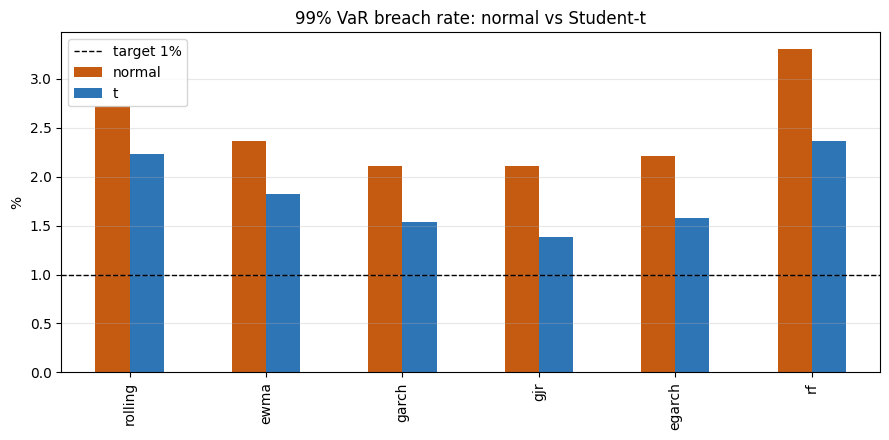

In [4]:
# Normal against Student-t, side by side. The dashed line is the 1 percent we want.
norm_rate = {m: var_backtest(r, fc[m], 0.99, "normal")["exception_rate"] * 100 for m in MODELS}
t_rate = {m: var_backtest(r, fc[m], 0.99, "t", nu=estimate_t_dof(r / fc[m]))["exception_rate"] * 100 for m in MODELS}
comp = pd.DataFrame({"normal": norm_rate, "t": t_rate})
fig, ax = plt.subplots(figsize=(9, 4.5))
comp.plot(kind="bar", ax=ax, color={"normal": "#c55a11", "t": "#2e75b6"})
ax.axhline(1.0, color="black", ls="--", lw=1, label="target 1%")
ax.set_title("99% VaR breach rate: normal vs Student-t"); ax.set_ylabel("%"); ax.legend(); ax.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

## 95 percent VaR

Step back from the extreme tail and the normal assumption is fine. Plain GARCH passes
both the count and the clustering test cleanly, which confirms it is only the far tail
where the bell curve breaks.

In [5]:
rows = []
for m in MODELS:
    res = var_backtest(r, fc[m], alpha=0.95, dist="normal")
    rows.append({"model": m, "rate_%": round(res["exception_rate"] * 100, 2),
                 "kupiec_p": round(res["kupiec_p"], 3), "cc_p": round(res["cc_p"], 3)})
pd.DataFrame(rows).set_index("model")

,rate_%,kupiec_p,cc_p
model,,,
rolling,6.53,0.000,0.000
ewma,5.92,0.006,0.021
garch,5.41,0.206,0.447
gjr,5.70,0.034,0.077
egarch,6.07,0.001,0.006
rf,7.63,0.000,0.000


## Where the breaches fall

Red dots mark the days the best model's 99 percent VaR was crossed. They are scattered
across the whole sample rather than piled into one crisis, which is the picture of a risk
model that keeps working when markets get rough.

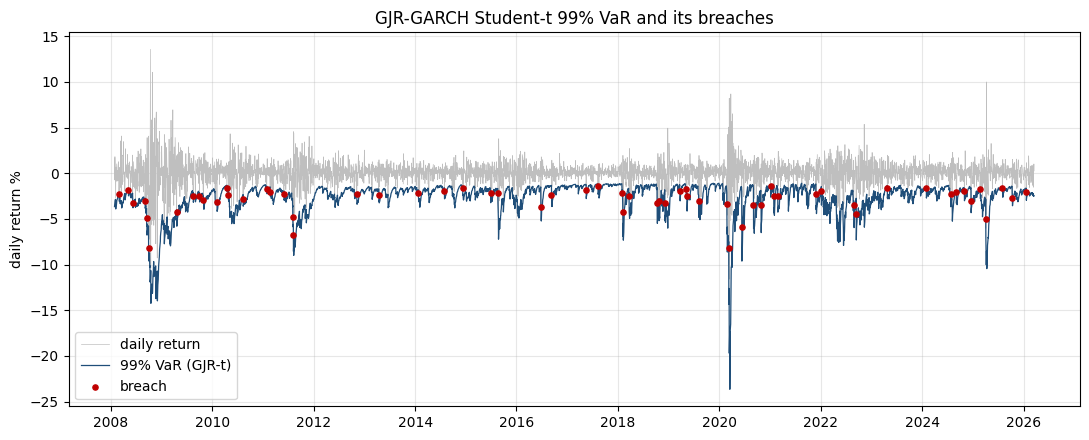

In [6]:
nu = estimate_t_dof(r / fc["gjr"])
var_line = var_series(fc["gjr"], 0.99, dist="t", nu=nu)
breaches = r[r < -var_line]
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(r.index, r * 100, color="#bfbfbf", lw=0.5, label="daily return")
ax.plot(r.index, -var_line * 100, color="#1f4e79", lw=0.9, label="99% VaR (GJR-t)")
ax.scatter(breaches.index, breaches * 100, color="#c00000", s=14, zorder=5, label="breach")
ax.set_title("GJR-GARCH Student-t 99% VaR and its breaches"); ax.set_ylabel("daily return %")
ax.legend(loc="lower left"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## The takeaway across all four notebooks

Notebook 02 said GJR-GARCH forecasts best. Notebook 03 said the simple models trade best.
This notebook says GJR-GARCH measures risk best. Three jobs, three answers. Which model
is right depends entirely on what you are asking it to do, and that is what makes
validating a model for its actual use so important.